In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [5]:
df = pd.read_csv("raw_rfm_sales_transactions_30000.csv")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30100 entries, 0 to 30099
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    30100 non-null  str    
 1   Date              30100 non-null  str    
 2   Product ID        30000 non-null  str    
 3   Product Name      30000 non-null  str    
 4   Product Category  30000 non-null  str    
 5   Quantity          30000 non-null  float64
 6   PPU               30000 non-null  str    
 7   Amount            30000 non-null  str    
dtypes: float64(1), str(7)
memory usage: 1.8 MB


We'll need to look into the non-null values and convert the data types. 

In [7]:
df["Date"].info()

<class 'pandas.Series'>
RangeIndex: 30100 entries, 0 to 30099
Series name: Date
Non-Null Count  Dtype
--------------  -----
30100 non-null  str  
dtypes: str(1)
memory usage: 235.3 KB


In [8]:
df.head(10)

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount
0,Customer-001,Yangon,NaN,NaN,NaN,NaN,NaN,NaN
1,T000001,01.01.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,8.0,"70,000","560,000"
2,T000002,01.01.2025,PROD-002,Wireless Mechanical Keyboard,Electronics,10.0,"380,000","3,800,000"
3,T000003,01.01.2025,PROD-004,Standing Desk Converter,Furniture,6.0,"500,000","3,000,000"
4,T000004,01.01.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,3.0,"25,500","76,500"
5,T000308,02.01.2025,PROD-002,Wireless Mechanical Keyboard,Electronics,10.0,"380,000","3,800,000"
6,T000614,03.01.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,10.0,"70,000","700,000"
7,T000615,03.01.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,1.0,"25,500","25,500"
8,T000912,04.01.2025,PROD-001,Ergonomic Mesh Chair,Furniture,6.0,"750,000","4,500,000"
9,T001206,05.01.2025,PROD-009,Adjustable Monitor Arm,Furniture,10.0,"195,000","1,950,000"


In [17]:
df

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount
0,Customer-001,Yangon,NaN,NaN,NaN,NaN,NaN,NaN
1,T000001,01.01.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,8.0,"70,000","560,000"
2,T000002,01.01.2025,PROD-002,Wireless Mechanical Keyboard,Electronics,10.0,"380,000","3,800,000"
3,T000003,01.01.2025,PROD-004,Standing Desk Converter,Furniture,6.0,"500,000","3,000,000"
4,T000004,01.01.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,3.0,"25,500","76,500"
...,...,...,...,...,...,...,...,...
30095,T029544,24.06.2025,PROD-007,USB-C Docking Station,Electronics,4.0,"340,000","1,360,000"
30096,T029545,24.06.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,2.0,"25,500","51,000"
30097,T029612,25.06.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,10.0,"70,000","700,000"
30098,T029681,26.06.2025,PROD-003,27-inch 4K Monitor,Electronics,6.0,"1,200,000","7,200,000"


In [9]:
df[df["Transaction ID"].astype(str).str.startswith("C")]

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount
0,Customer-001,Yangon,NaN,NaN,NaN,NaN,NaN,NaN
323,Customer-002,Bago,NaN,NaN,NaN,NaN,NaN,NaN
586,Customer-003,Naypyitaw,NaN,NaN,NaN,NaN,NaN,NaN
874,Customer-004,Taunggyi,NaN,NaN,NaN,NaN,NaN,NaN
1193,Customer-005,Bago,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
28595,Customer-096,Taunggyi,NaN,NaN,NaN,NaN,NaN,NaN
28909,Customer-097,Yangon,NaN,NaN,NaN,NaN,NaN,NaN
29205,Customer-098,Taunggyi,NaN,NaN,NaN,NaN,NaN,NaN
29511,Customer-099,Mandalay,NaN,NaN,NaN,NaN,NaN,NaN


Customer IDs have been mixed up wih Transaction IDs. Equally, region has been mixed up with Date. 

In [10]:
# detect customer rows
is_customer = df["Transaction ID"].astype(str).str.startswith("Customer")

# create new column, only fill customer rows
df["Customer"] = df["Transaction ID"].where(is_customer)

# forward fill to assign customer to all transaction rows
df["Customer"] = df["Customer"].ffill()

#same thing with region
is_region = pd.to_datetime(df["Date"], errors="coerce").isna()
df["Region"] = df["Date"].where(is_region)
df["Region"] = df["Region"].ffill()


/var/folders/fb/1dsscbz90js5g1s34l0bg5cr0000gn/T/ipykernel_28830/2861462439.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  is_region = pd.to_datetime(df["Date"], errors="coerce").isna()


In [11]:
df

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount,Customer,Region
0,Customer-001,Yangon,NaN,NaN,NaN,NaN,NaN,NaN,Customer-001,Yangon
1,T000001,01.01.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,8.0,"70,000","560,000",Customer-001,Yangon
2,T000002,01.01.2025,PROD-002,Wireless Mechanical Keyboard,Electronics,10.0,"380,000","3,800,000",Customer-001,Yangon
3,T000003,01.01.2025,PROD-004,Standing Desk Converter,Furniture,6.0,"500,000","3,000,000",Customer-001,Yangon
4,T000004,01.01.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,3.0,"25,500","76,500",Customer-001,Yangon
...,...,...,...,...,...,...,...,...,...,...
30095,T029544,24.06.2025,PROD-007,USB-C Docking Station,Electronics,4.0,"340,000","1,360,000",Customer-100,Mandalay
30096,T029545,24.06.2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,2.0,"25,500","51,000",Customer-100,Mandalay
30097,T029612,25.06.2025,PROD-008,Executive Ballpoint Pen Box,Office Supplies,10.0,"70,000","700,000",Customer-100,Mandalay
30098,T029681,26.06.2025,PROD-003,27-inch 4K Monitor,Electronics,6.0,"1,200,000","7,200,000",Customer-100,Mandalay


Bad dates seem to be missing data for all other columns as well. We can safely drop them. 

In [12]:
#Drop all values that are bad dates/trasnaction id

clean_df = df.loc[~is_region]

In [13]:
len(clean_df)/len(df)

0.9966777408637874

We still have 99% of the original dataset available to us.

In [16]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 30000 entries, 1 to 30099
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    30000 non-null  str    
 1   Date              30000 non-null  str    
 2   Product ID        30000 non-null  str    
 3   Product Name      30000 non-null  str    
 4   Product Category  30000 non-null  str    
 5   Quantity          30000 non-null  float64
 6   PPU               30000 non-null  str    
 7   Amount            30000 non-null  str    
 8   Customer          30000 non-null  str    
 9   Region            30000 non-null  str    
dtypes: float64(1), str(9)
memory usage: 2.5 MB


In [17]:
clean_df["Date"] = pd.to_datetime(clean_df["Date"], errors="coerce", dayfirst=True)

clean_df["Amount"] = pd.to_numeric(
    clean_df["Amount"].replace({r"[$,]": ""}, regex=True),
    errors="coerce"
)

clean_df["PPU"] = pd.to_numeric(
    clean_df["PPU"].replace({r"[$,]": ""}, regex=True),
    errors="coerce"
)

In [18]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 30000 entries, 1 to 30099
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    30000 non-null  str           
 1   Date              30000 non-null  datetime64[us]
 2   Product ID        30000 non-null  str           
 3   Product Name      30000 non-null  str           
 4   Product Category  30000 non-null  str           
 5   Quantity          30000 non-null  float64       
 6   PPU               30000 non-null  int64         
 7   Amount            30000 non-null  int64         
 8   Customer          30000 non-null  str           
 9   Region            30000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 2.5 MB


In [19]:
#Format numbers to show 2 decimal points
pd.set_option('display.float_format', '{:.2f}'.format)

clean_df.describe()

,Date,Quantity,PPU,Amount
count,30000,30000.00,30000.00,30000.00
mean,2025-03-06 06:42:34.560000,5.49,450436.20,2468430.98
min,2025-01-01 00:00:00,1.00,25500.00,25500.00
25%,2025-01-25 00:00:00,3.00,180000.00,540000.00
50%,2025-02-19 00:00:00,5.00,340000.00,1520000.00
75%,2025-04-09 00:00:00,8.00,750000.00,3500000.00
max,2025-06-30 00:00:00,10.00,1200000.00,12000000.00
std,NaN,2.88,364835.65,2596339.52


In [20]:
clean_df.columns

Index(['Transaction ID', 'Date', 'Product ID', 'Product Name',
       'Product Category', 'Quantity', 'PPU', 'Amount', 'Customer', 'Region'],
      dtype='str')

In [30]:
clean_df["Transaction ID"].unique()

<StringArray>
['T000001', 'T000002', 'T000003', 'T000004', 'T000308', 'T000614', 'T000615',
 'T000912', 'T001206', 'T001521',
 ...
 'T029280', 'T029348', 'T029408', 'T029409', 'T029476', 'T029544', 'T029545',
 'T029612', 'T029681', 'T029829']
Length: 30000, dtype: str

Each Transaction ID is unique. 

In [33]:
clean_df["Customer"].value_counts()


Customer
Customer-016    344
Customer-078    341
Customer-027    334
Customer-093    330
Customer-094    329
               ... 
Customer-080    272
Customer-084    270
Customer-017    269
Customer-054    269
Customer-002    262
Name: count, Length: 100, dtype: int64

In [34]:
clean_df["Region"].value_counts()

Region
Mandalay     9051
Bago         6537
Taunggyi     5574
Naypyitaw    5307
Yangon       3531
Name: count, dtype: int64

In [17]:
clean_df["Product Category"].unique()

<StringArray>
['Office Supplies', 'Electronics', 'Furniture']
Length: 3, dtype: str

**Product Performance Analysis**

I want to answer the following questions: 

- Which products generate the most revenue?
- Which products sell the most units?
- Which categories drive sales?
- What products have high revenue but low volume?
- What products have high volume but low revenue?

In [18]:
clean_df.groupby("Product Name")["Amount"].sum().sort_values(ascending=False)

Product Name
27-inch 4K Monitor               19454400000
Noise-Cancelling Headphones      14519700000
Ergonomic Mesh Chair             12062250000
Standing Desk Converter           8209500000
Wireless Mechanical Keyboard      6399580000
USB-C Docking Station             5558660000
Adjustable Monitor Arm            3219840000
Webcam 1080p HD                   3065580000
Executive Ballpoint Pen Box       1130710000
A4 Printer Paper (500 Sheets)      432709500
Name: Amount, dtype: int64

In [19]:
clean_df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False)

Product Name
Webcam 1080p HD                 17031.00
A4 Printer Paper (500 Sheets)   16969.00
Wireless Mechanical Keyboard    16841.00
Adjustable Monitor Arm          16512.00
Standing Desk Converter         16419.00
USB-C Docking Station           16349.00
27-inch 4K Monitor              16212.00
Executive Ballpoint Pen Box     16153.00
Noise-Cancelling Headphones     16133.00
Ergonomic Mesh Chair            16083.00
Name: Quantity, dtype: float64

In [20]:
clean_df.groupby("Product Category")["Amount"].sum().sort_values(ascending=False)

Product Category
Electronics        48997920000
Furniture          23491590000
Office Supplies     1563419500
Name: Amount, dtype: int64

In [21]:
product_perf = clean_df.groupby(
    ["Product ID", "Product Name", "Product Category"]
).agg(
    Revenue = ("Amount", "sum"),
    Units_Sold = ("Quantity", "sum")
).reset_index()

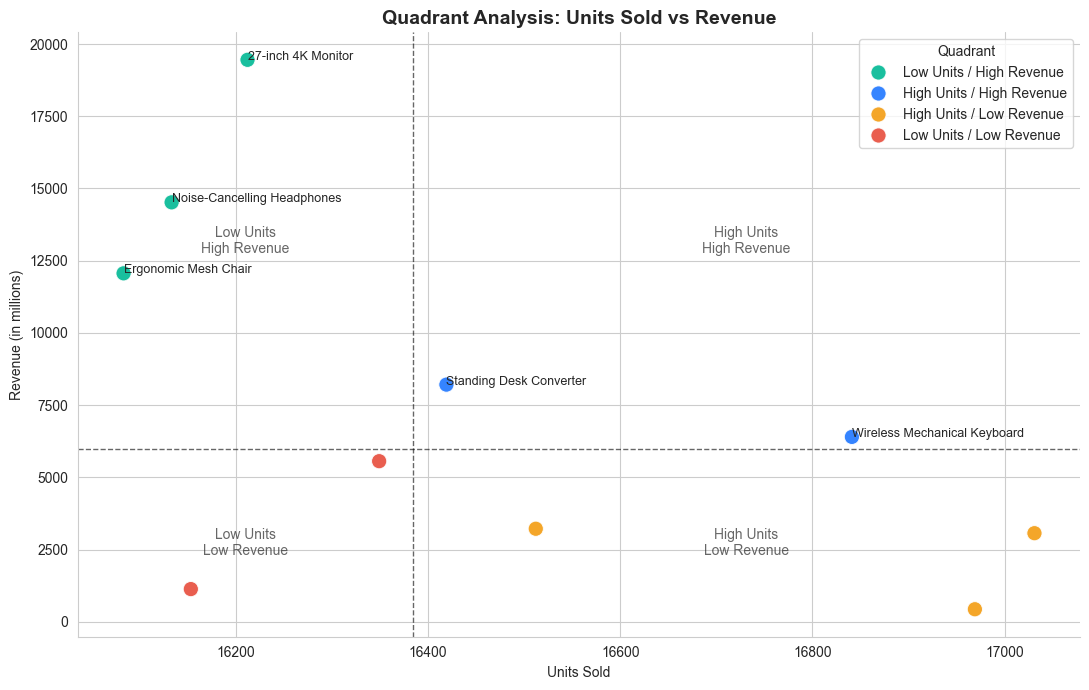

In [22]:
# ---- Prep ---
product_perf["Revenue (in millions)"] = product_perf["Revenue"] / 1_000_000

x = product_perf["Units_Sold"]
y = product_perf["Revenue (in millions)"]

med_x = x.median()
med_y = y.median()

# ---- Quadrant labels ----
def label_quadrant(row):
    if row["Units_Sold"] >= med_x and row["Revenue (in millions)"] >= med_y:
        return "High Units / High Revenue"
    elif row["Units_Sold"] < med_x and row["Revenue (in millions)"] >= med_y:
        return "Low Units / High Revenue"
    elif row["Units_Sold"] >= med_x and row["Revenue (in millions)"] < med_y:
        return "High Units / Low Revenue"
    else:
        return "Low Units / Low Revenue"

product_perf["Quadrant"] = product_perf.apply(label_quadrant, axis=1)

# ---- Style ----
plt.figure(figsize=(11, 7))
sns.set_style("whitegrid")

palette = {
    "High Units / High Revenue": "#1f77ff",
    "Low Units / High Revenue": "#00b894",
    "High Units / Low Revenue": "#f39c12",
    "Low Units / Low Revenue": "#e74c3c"
}

# ---- Scatter ----
sns.scatterplot(
    data=product_perf,
    x="Units_Sold",
    y="Revenue (in millions)",
    hue="Quadrant",
    palette=palette,
    s=120,
    edgecolor="white",
    linewidth=0.7,
    alpha=0.9
)

# ---- Median lines (quadrants) ----
plt.axvline(med_x, linestyle="--", color="black", linewidth=1, alpha=0.6)
plt.axhline(med_y, linestyle="--", color="black", linewidth=1, alpha=0.6)

# ---- Quadrant labels (centered in each region) ----
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

plt.text((xmin + med_x)/2, (ymax + med_y)/2, "Low Units\nHigh Revenue",
         ha="center", va="center", fontsize=10, alpha=0.7)

plt.text((med_x + xmax)/2, (ymax + med_y)/2, "High Units\nHigh Revenue",
         ha="center", va="center", fontsize=10, alpha=0.7)

plt.text((xmin + med_x)/2, (ymin + med_y)/2, "Low Units\nLow Revenue",
         ha="center", va="center", fontsize=10, alpha=0.7)

plt.text((med_x + xmax)/2, (ymin + med_y)/2, "High Units\nLow Revenue",
         ha="center", va="center", fontsize=10, alpha=0.7)

# ---- Optional: label top performers ----
top = product_perf.nlargest(5, "Revenue (in millions)")
for _, row in top.iterrows():
    plt.text(row["Units_Sold"], row["Revenue (in millions)"], 
             row["Product Name"], fontsize=9, ha="left")

# ---- Clean finish ----
plt.title("Quadrant Analysis: Units Sold vs Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Units Sold")
plt.ylabel("Revenue (in millions)")

plt.savefig("charts/Quadrant_Analysis.png", dpi=300, bbox_inches="tight")


sns.despine()
plt.tight_layout()
plt.show()

Premium Products: 
- ergonomic mesh chair, 
- noise cancelling headphones, 
- 27 inch 4k monitor


Star Products: 
- standing desk converter
- wireless mechanical keyboard

Volume Drivers:  
- adjustable monitor arm, 
- webcam  1080p hd 
- a4 printer paper

Underperformers: 
- executive ballpoint pen box 
- usb c docking station



In [23]:
pareto = product_perf.sort_values('Revenue (in millions)', ascending=False)

pareto['Revenue_Pct'] = (
    pareto['Revenue (in millions)'] /
    pareto['Revenue (in millions)'].sum()
)

pareto['Cum_Pct'] = (pareto['Revenue_Pct'].cumsum()* 100)

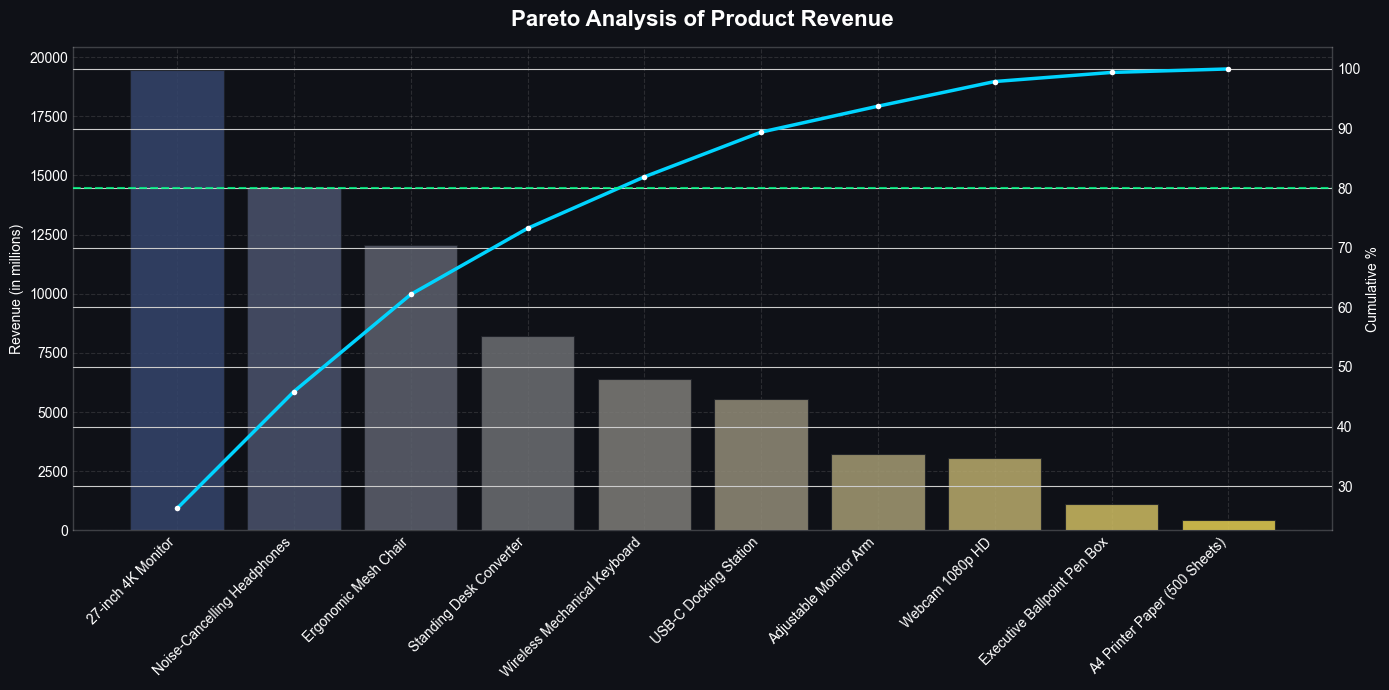

In [24]:
import numpy as np

# ---- Figure setup  ----
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#0f1117") 
ax1.set_facecolor("#0f1117")

# ---- Bars  ----
colors = plt.cm.cividis(np.linspace(0.2, 0.9, len(pareto)))

bars = ax1.bar(
    range(len(pareto)),
    pareto['Revenue (in millions)'],
    color=colors,
    alpha=0.85,
    edgecolor="#1c1f26",
    linewidth=0.8
)

# ---- Secondary axis  ----
ax2 = ax1.twinx()

ax2.plot(
    pareto["Product Name"],
    pareto['Cum_Pct'],
    color="#00d4ff",
    linewidth=2.5,
    marker="o",
    markersize=4,
    markerfacecolor="white",
    markeredgewidth=0
)

ax2.axhline(
    80,
    linestyle="--",
    color="#00ff88",
    linewidth=1.5,
    alpha=0.8
)

# ---- X labels ----
ax1.set_xticks(range(len(pareto)))
ax1.set_xticklabels(pareto["Product Name"], rotation=45, ha='right', color="white")

# ---- Styling details ----
ax1.tick_params(colors="white")
ax2.tick_params(colors="white")

for spine in ax1.spines.values():
    spine.set_alpha(0.2)
    spine.set_color("white")

for spine in ax2.spines.values():
    spine.set_alpha(0)

ax1.set_title(
    "Pareto Analysis of Product Revenue",
    color="white",
    fontsize=16,
    pad=15,
    fontweight="bold"
)

ax1.set_ylabel("Revenue (in millions)", color="white")
ax2.set_ylabel("Cumulative %", color="white")

ax1.grid(True, linestyle="--", alpha=0.15)
plt.savefig("charts/Pareto_Analysis.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

The Pareto analysis shows a strong revenue concentration within a small subset of high-value products.

The cumulative revenue curve reaches the 80% threshold at the Wireless Mechanical Keyboard, indicating that a limited group of products (Premium Products and Star Products) is responsible for the vast majority of revenue.

This structure suggests:

- Inventory strategy should prioritize these high-impact products
- Marketing spend should be disproportionately allocated to **Star products**
- **Premium products** should be protected as margin drivers rather than volume drivers
- Long-tail products contribute marginal revenue and may be optimized for efficiency rather than growth

In [26]:
import plotly.express as px

fig = px.treemap(
    product_perf,
    path=[
        'Product Category',
        'Product Name'
    ],
    values='Revenue',
    title='Revenue by Category and Product'
)

fig.write_image("charts/category_tree.png", scale=2)

fig.show(renderer = "browser")

The treemap reveals a clear imbalance in revenue contribution across product categories:

- Electronics is the dominant category by a significant margin
- Furniture is the second-largest contributor
- Office Supplies represents a relatively small share of total revenue

Revenue is heavily concentrated in Electronics, indicating that the business is structurally dependent on a single dominant category. Furniture provides secondary stability, while Office Supplies plays a long-tail role with limited revenue impact.

**Customer Segmentation**

I want to segment customers based on recency and frequency of purchases, as well as amount spent (RFM model). 

In [22]:
snapshot_date = clean_df['Date'].max() + pd.Timedelta(days=1)

rfm = clean_df.groupby('Customer').agg(
    Recency=('Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Transaction ID', 'nunique'),
    Monetary=('Amount', 'sum')
).reset_index()

rfm

,Customer,Recency,Frequency,Monetary
0,Customer-001,1,322,784745000
1,Customer-002,1,262,679040500
2,Customer-003,2,287,736283000
3,Customer-004,1,318,689126000
4,Customer-005,1,311,765826500
...,...,...,...,...
95,Customer-096,1,313,829229500
96,Customer-097,1,295,735736000
97,Customer-098,1,305,715626000
98,Customer-099,2,295,700938500


In [41]:
rfm.describe()

,Recency,Frequency,Monetary
count,100.00,100.00,100.00
mean,50.00,300.00,740529295.00
std,55.39,17.00,59354218.79
min,1.00,262.00,586206500.00
25%,1.00,289.00,699733000.00
50%,32.00,300.50,736860750.00
75%,95.25,313.00,785371500.00
max,132.00,344.00,880893000.00


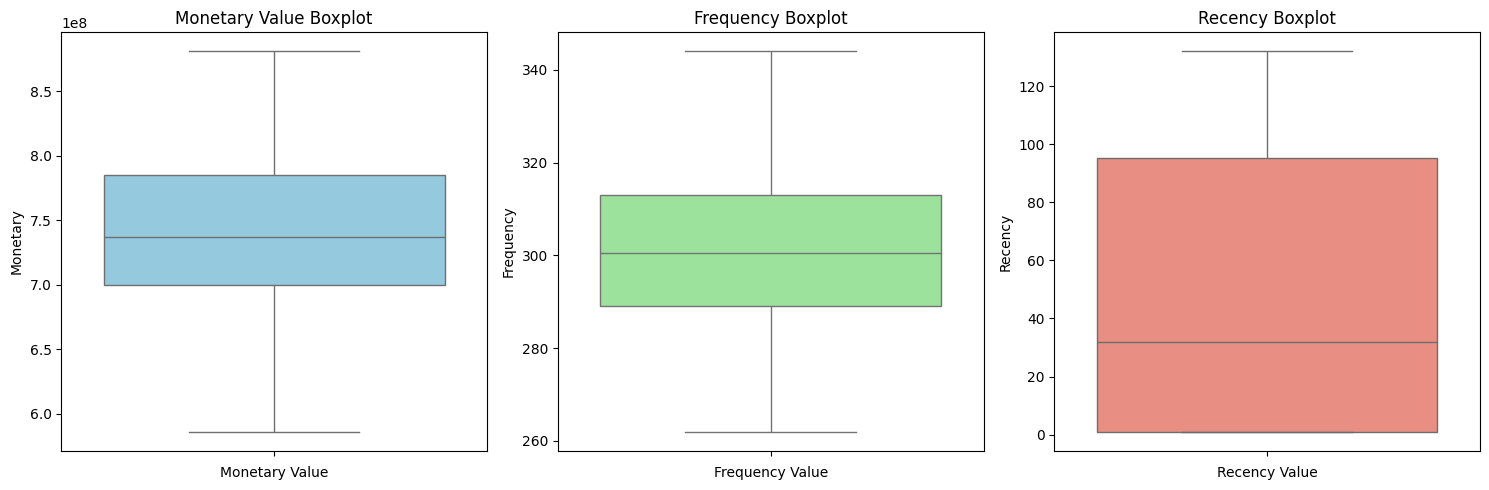

In [23]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data= rfm["Monetary"], color="skyblue")
plt.title("Monetary Value Boxplot")
plt.xlabel("Monetary Value")

plt.subplot(1, 3, 2)
sns.boxplot(data = rfm["Frequency"], color="lightgreen")
plt.title("Frequency Boxplot")
plt.xlabel("Frequency Value")

plt.subplot(1, 3, 3)
sns.boxplot(data = rfm["Recency"], color="salmon")
plt.title("Recency Boxplot")
plt.xlabel("Recency Value")

plt.tight_layout()
plt.show()

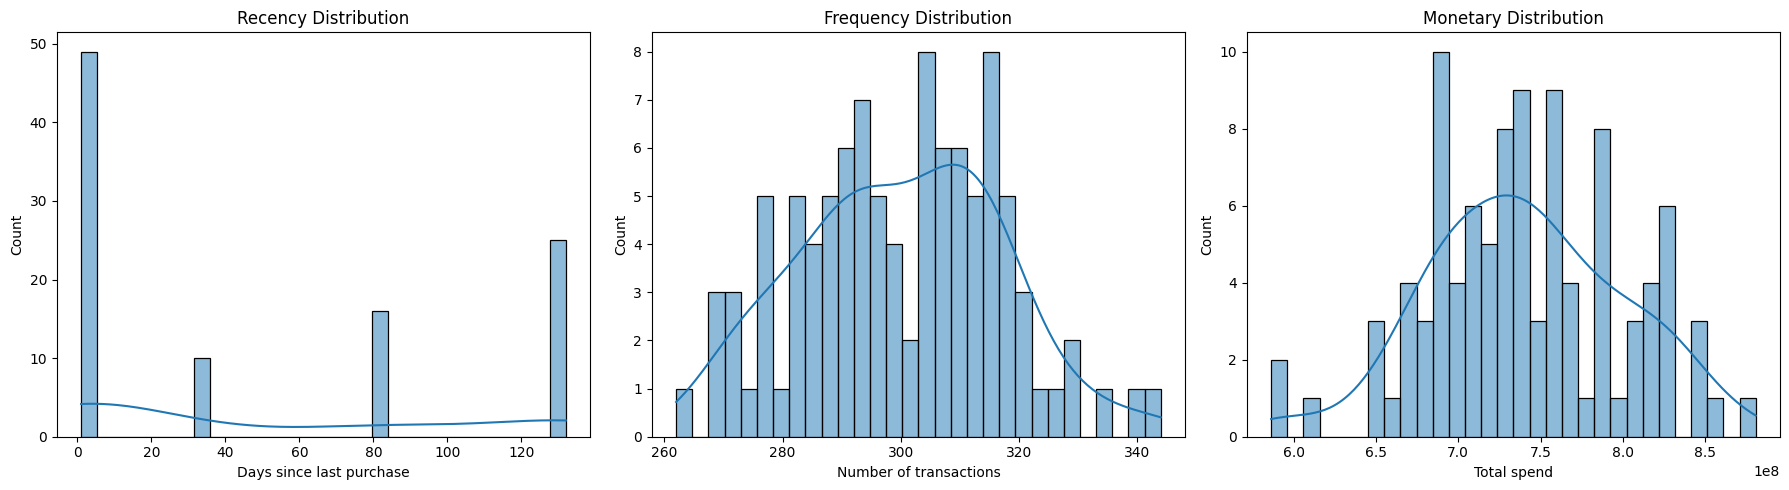

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# --- Recency ---
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")

# --- Frequency ---
sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of transactions")

# --- Monetary ---
sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total spend")

plt.tight_layout()
plt.show()

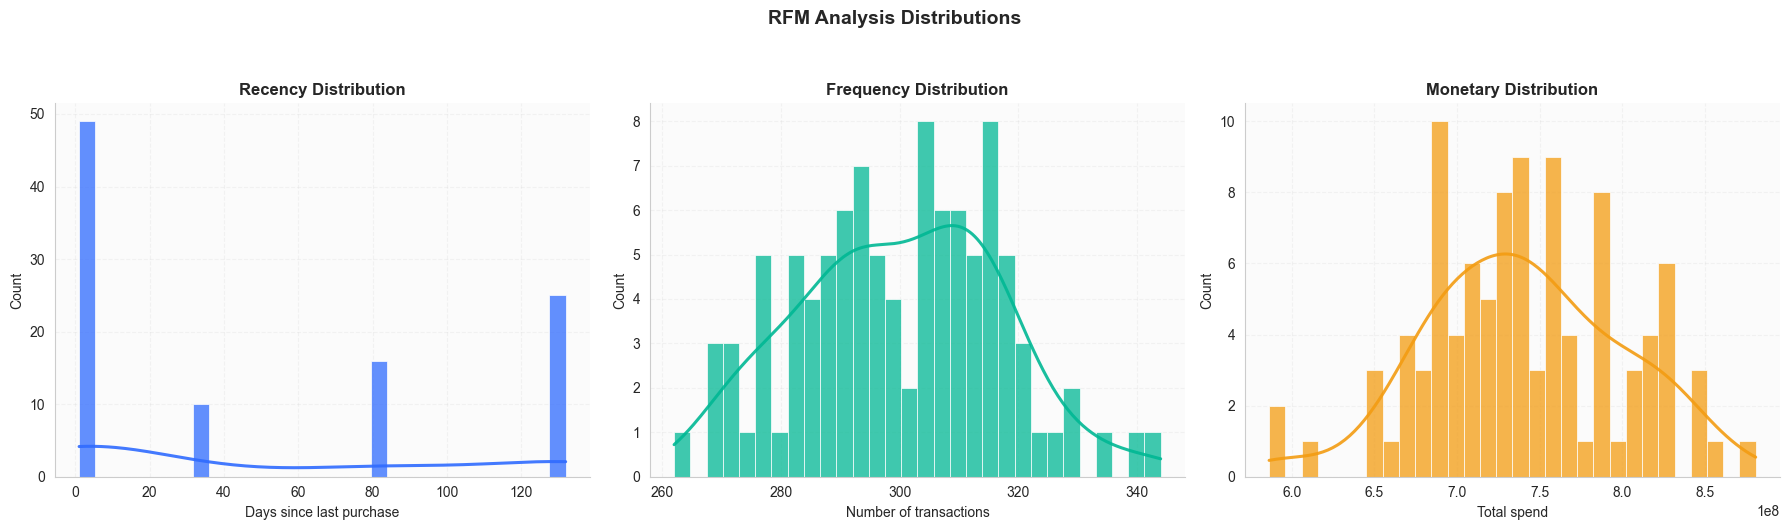

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Style ----
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#ffffff")

hist_style = {
    "bins": 30,
    "kde": True,
    "line_kws": {"linewidth": 2.2, "alpha": 0.9},
    "alpha": 0.75,
    "edgecolor": "white",
    "linewidth": 0.5
}

# ---- Recency ----
sns.histplot(
    rfm["Recency"],
    ax=axes[0],
    color="#2F6BFF",
    **hist_style
)
axes[0].set_title("Recency Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Days since last purchase")

# ---- Frequency ----
sns.histplot(
    rfm["Frequency"],
    ax=axes[1],
    color="#00B894",
    **hist_style
)
axes[1].set_title("Frequency Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of transactions")

# ---- Monetary ----
sns.histplot(
    rfm["Monetary"],
    ax=axes[2],
    color="#F39C12",
    **hist_style
)
axes[2].set_title("Monetary Distribution", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Total spend")

# ---- Clean finishing touches ----
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.2)
    ax.set_facecolor("#fbfbfb")
    sns.despine(ax=ax)

plt.suptitle("RFM Analysis Distributions", fontsize=14, fontweight="bold", y=1.05)

plt.savefig("charts/RFM_Distributions.png", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

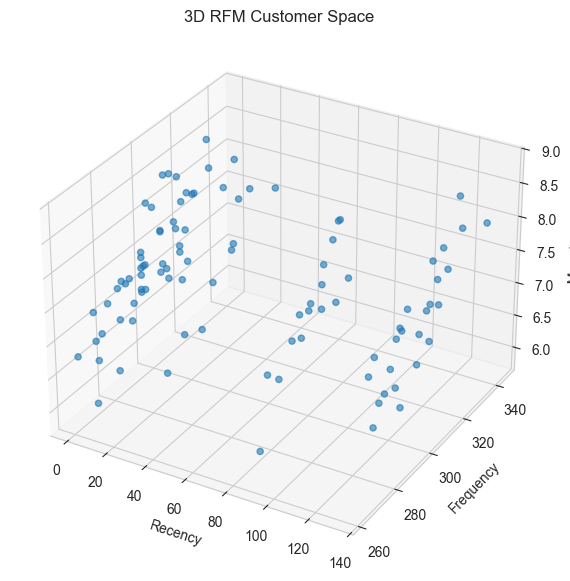

In [62]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    alpha=0.6
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("3D RFM Customer Space")

plt.savefig("charts/3d_RFM.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
rfm[['Recency', 'Frequency', 'Monetary']].skew()

Recency      0.52
Frequency    0.05
Monetary    -0.03
dtype: float64

Skewness analysis showed that Recency (0.52), Frequency (0.05), and Monetary (-0.03) exhibited minimal skewness. Therefore, no logarithmic transformation was required, and features were standardized directly prior to K-Means clustering.

In [64]:
from sklearn.preprocessing import StandardScaler

features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)


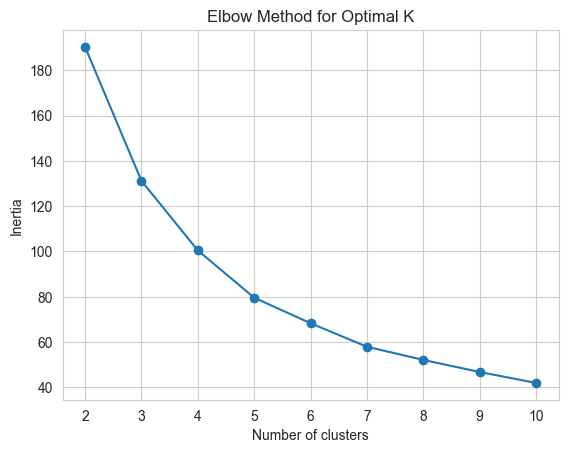

In [65]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [66]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [67]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,8.31,314.96,787500461.54
1,114.41,313.94,794637264.71
2,111.17,290.08,707354104.17
3,5.18,288.24,699775318.18


In [68]:
rfm.head(10)

,Customer,Recency,Frequency,Monetary,Recency_Bucket,Cluster
0,Customer-001,1,322,784745000,0-7,0
1,Customer-002,1,262,679040500,0-7,3
2,Customer-003,2,287,736283000,0-7,3
3,Customer-004,1,318,689126000,0-7,0
4,Customer-005,1,311,765826500,0-7,0
5,Customer-006,1,304,768630500,0-7,0
6,Customer-007,1,277,721813000,0-7,3
7,Customer-008,1,289,666560500,0-7,3
8,Customer-009,1,294,698389000,0-7,3
9,Customer-010,1,294,724276500,0-7,3


In [69]:
rfm[['Recency','Frequency','Monetary']].describe()

,Recency,Frequency,Monetary
count,100.00,100.00,100.00
mean,50.00,300.00,740529295.00
std,55.39,17.00,59354218.79
min,1.00,262.00,586206500.00
25%,1.00,289.00,699733000.00
50%,32.00,300.50,736860750.00
75%,95.25,313.00,785371500.00
max,132.00,344.00,880893000.00
